In [73]:
# Final Project: Microplastic Pollution in the Gulf of Mexico

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from scipy import stats
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Cleaning up the dataframe 
df = pd.read_csv("Marine Microplastic Concentrations.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df = df.sort_values(by='Date', ascending=True)
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index('Date')))
df = df[cols]
df = df[df["Microplastics Measurement (density)"] > 0]

df

,Date,OBJECTID,Oceans,Regions,SubRegions,Sampling Method,Microplastics Measurement (density),Unit,Density Class Range,Concentration Class,...,DOI,Organization,Keywords,NCEI Accession Number,NCEI Accession Link,Latitude,Longitude,x,y,Year
1247,2000-09-16,10673,Pacific Ocean,NaN,NaN,Manta net,0.027000,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1371/journal.pone.0080020,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,1.200,-110.816,-1.233598e+07,133593.156,2000
1195,2000-09-17,10674,Pacific Ocean,NaN,NaN,Manta net,0.024000,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1371/journal.pone.0080020,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,4.116,-110.050,-1.225071e+07,458585.628,2000
1196,2000-09-18,10675,Pacific Ocean,NaN,NaN,Manta net,0.033000,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1371/journal.pone.0080020,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,3.200,-107.266,-1.194080e+07,356407.708,2000
1187,2000-09-21,10676,Pacific Ocean,NaN,NaN,Manta net,0.005000,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1371/journal.pone.0080020,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,4.733,-98.066,-1.091666e+07,527475.391,2000
1175,2000-10-07,10677,Pacific Ocean,NaN,NaN,Manta net,0.044000,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1371/journal.pone.0080020,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,4.033,-92.116,-1.025431e+07,449322.698,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,2010-12-09,8036,Pacific Ocean,NaN,NaN,Neuston net,2.611356,pieces/m3,1-10,High,...,https://doi.org/10.1021/es4053076,Sea Education Association,SEA,211008,https://www.ncei.noaa.gov/access/metadata/land...,40.680,-128.900,-1.434908e+07,4965255.702,2010
978,2010-12-09,8037,Pacific Ocean,NaN,NaN,Neuston net,0.043748,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1021/es4053076,Sea Education Association,SEA,211008,https://www.ncei.noaa.gov/access/metadata/land...,40.580,-157.790,-1.756510e+07,4950587.754,2010
845,2010-12-18,8044,Pacific Ocean,NaN,NaN,Neuston net,0.002660,pieces/m3,0.0005-0.005,Low,...,https://doi.org/10.1021/es4053076,Sea Education Association,SEA,211008,https://www.ncei.noaa.gov/access/metadata/land...,33.090,-156.270,-1.739590e+07,3907256.060,2010
770,2010-12-19,8048,Pacific Ocean,NaN,NaN,Neuston net,0.008640,pieces/m3,0.005-1,Medium,...,https://doi.org/10.1021/es4053076,Sea Education Association,SEA,211008,https://www.ncei.noaa.gov/access/metadata/land...,33.470,-151.630,-1.687937e+07,3957856.065,2010


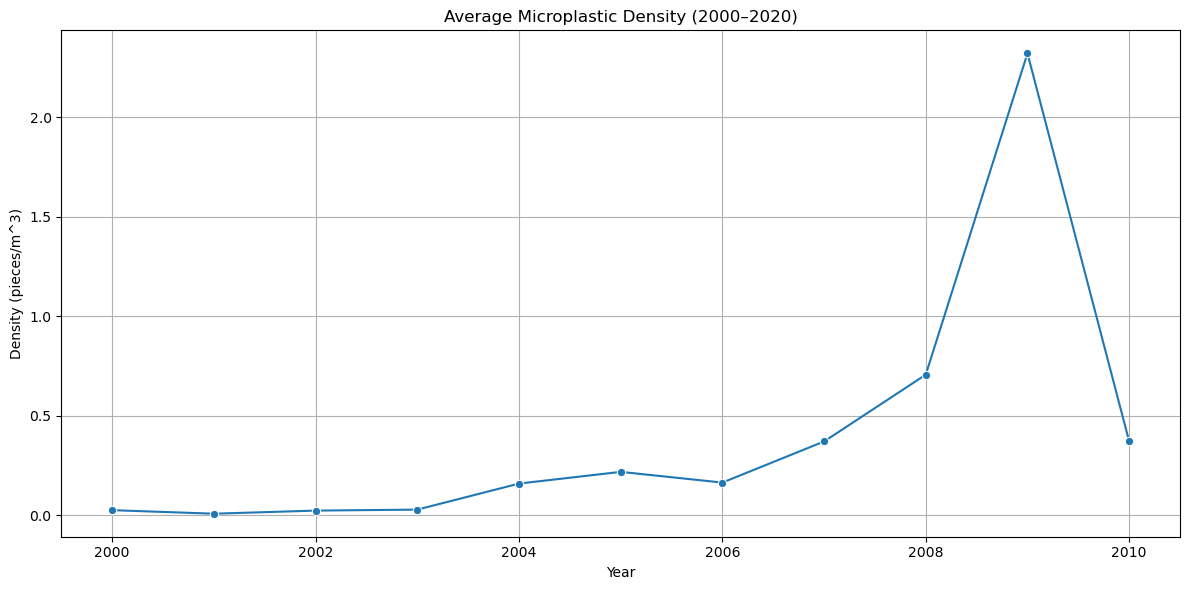

In [63]:
# Creating a temporal visual to see how microplastic concentration has changed over 10 years (2000 to 2010)
df_temporal = df.groupby('Year')["Microplastics Measurement (density)"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_temporal, x='Year', y="Microplastics Measurement (density)", marker='o')
plt.title('Average Microplastic Density (2000–2020)')
plt.xlabel('Year')
plt.ylabel('Density (pieces/m^3)')
plt.grid(True)
plt.tight_layout()
plt.show()

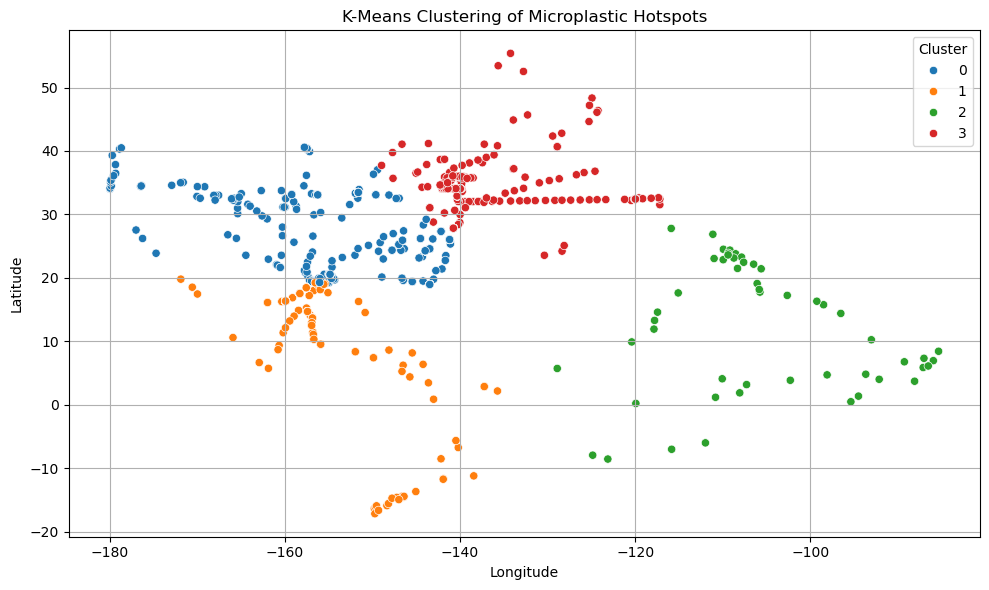

In [67]:
# Use K-Means clustering to identify geographic hotspots of microplastic concentrations

coords = df[['Latitude', 'Longitude']]
coords_scaled = StandardScaler().fit_transform(coords)

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(coords_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Cluster', palette='tab10')
plt.title('K-Means Clustering of Microplastic Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
# Apply classification models 

df_class = df[['Year', 'Latitude', 'Longitude', 'Concentration Class']].dropna()
X = df_class[['Year', 'Latitude', 'Longitude']]
y = df_class['Concentration Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

# SVM
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

print("KNN Classification Report:")
print(classification_report(y_test, knn_preds))

print("SVM Classification Report:")
print(classification_report(y_test, svm_preds))

KNN Classification Report:
              precision    recall  f1-score   support

        High       0.58      0.79      0.67        43
         Low       0.81      0.78      0.79        94
      Medium       0.81      0.76      0.78       148
   Very High       0.00      0.00      0.00         3

    accuracy                           0.76       288
   macro avg       0.55      0.58      0.56       288
weighted avg       0.76      0.76      0.76       288

SVM Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        43
         Low       0.00      0.00      0.00        94
      Medium       0.51      1.00      0.68       148
   Very High       0.00      0.00      0.00         3

    accuracy                           0.51       288
   macro avg       0.13      0.25      0.17       288
weighted avg       0.26      0.51      0.35       288



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-pa

In [71]:
# Statistical testing to compare microplastic density between the two classes

density_classes = df['Concentration Class'].dropna().unique()
if len(density_classes) >= 2:
    group1 = df[df['Concentration Class'] == density_classes[0]]["Microplastics Measurement (density)"]
    group2 = df[df['Concentration Class'] == density_classes[1]]["Microplastics Measurement (density)"]
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    print(f"T-test between '{density_classes[0]}' and '{density_classes[1]}':")
    print(f"  T-statistic = {t_stat:.3f}")
    print(f"  P-value = {p_val:.3e}")
else:
    print("Not enough unique concentration classes for a t-test.")

T-test between 'Medium' and 'Low':
  T-statistic = 13.262
  P-value = 1.070e-34


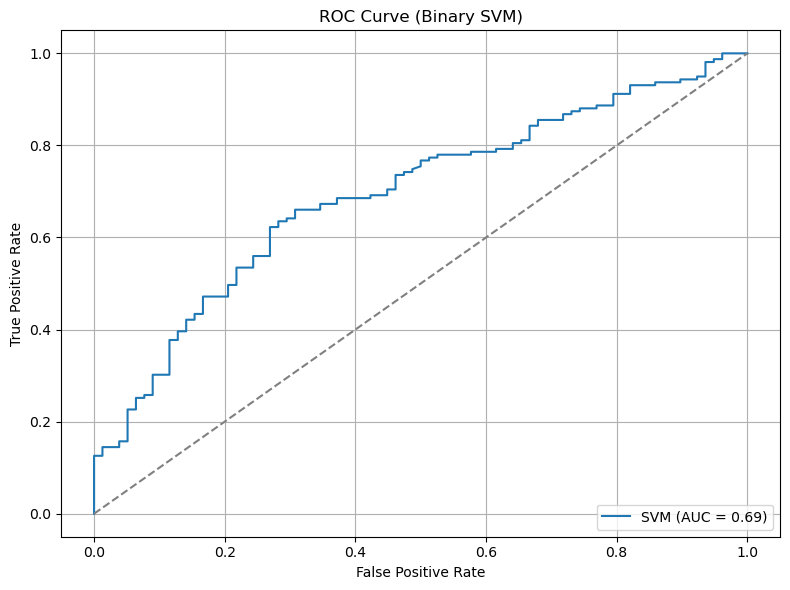

In [77]:
# ROC curve and AUC

binary_classes = y.isin([density_classes[0], density_classes[1]])
X_binary = X[binary_classes]
y_binary = y[binary_classes]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)

svm_bin = SVC(kernel='rbf', probability=True)
svm_bin.fit(X_train_bin, y_train_bin)

y_prob = svm_bin.predict_proba(X_test_bin)[:, 1]
lb = LabelBinarizer()
y_test_bin_binary = lb.fit_transform(y_test_bin).ravel()

fpr, tpr, _ = roc_curve(y_test_bin_binary, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary SVM)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()